# Part 2c: Custom Metrics in Deep Learning

## Overview

In this notebook, we'll explore how to create **custom metrics** in both TensorFlow/Keras and PyTorch. Custom metrics are essential when built-in metrics don't capture the specific performance aspects you need to track.

### Topics Covered:
1. **HuberMetric** - A robust metric for regression tasks
2. **F1 Score** - Harmonic mean of precision and recall
3. **Streaming/Stateful Metrics** - Metrics that accumulate over batches
4. **Multi-class metrics** - Macro, Micro, and Weighted averages

### Why Custom Metrics?
- Built-in metrics may not capture domain-specific requirements
- Some metrics require stateful computation across batches
- Custom metrics allow for more nuanced model evaluation

In [1]:
# Install required packages (for Google Colab)
!pip install -q tensorflow torch torchmetrics scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.6 MB/s eta 0:00:00


In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K

# PyTorch imports
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torchmetrics

# Sklearn for comparison
from sklearn.metrics import f1_score, precision_score, recall_score

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")

TensorFlow version: 2.19.0
PyTorch version: 2.10.0+cu128


---

## 1. Understanding Metrics in Deep Learning

Metrics differ from loss functions:
- **Loss functions** must be differentiable for gradient-based optimization
- **Metrics** are used for evaluation only, don't need to be differentiable

### Types of Metrics:

| Type | Description | Example |
|------|-------------|--------|
| **Stateless** | Computed per batch independently | Accuracy |
| **Stateful/Streaming** | Accumulates state across batches | Mean |
| **Threshold-based** | Requires prediction thresholding | F1 Score |

---

## 2. Custom HuberMetric

The Huber metric is useful for regression tasks as it's less sensitive to outliers than MSE.

### Mathematical Definition:

$$
L_\delta(y, \hat{y}) =
\begin{cases}
\frac{1}{2}(y - \hat{y})^2 & \text{if } |y - \hat{y}| \leq \delta \\
\delta |y - \hat{y}| - \frac{1}{2}\delta^2 & \text{otherwise}
\end{cases}
$$

### 2.1 TensorFlow/Keras Implementation

In [3]:
class HuberMetric(keras.metrics.Metric):
    """
    Custom Huber Metric for regression tasks.

    The Huber metric is robust to outliers - it behaves like MSE for small errors
    and like MAE for large errors.

    Parameters:
    -----------
    delta : float
        The threshold at which to change from quadratic to linear.
    """

    def __init__(self, delta=1.0, name='huber_metric', **kwargs):
        super().__init__(name=name, **kwargs)
        self.delta = delta
        # State variables for streaming computation
        self.total = self.add_weight(name='total', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        """Update the metric state with new batch data."""
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        error = y_true - y_pred
        abs_error = tf.abs(error)

        # Huber calculation
        quadratic = tf.minimum(abs_error, self.delta)
        linear = abs_error - quadratic
        huber_values = 0.5 * tf.square(quadratic) + self.delta * linear

        # Apply sample weights if provided
        if sample_weight is not None:
            sample_weight = tf.cast(sample_weight, tf.float32)
            huber_values = huber_values * sample_weight

        self.total.assign_add(tf.reduce_sum(huber_values))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self):
        """Compute the final metric value."""
        return self.total / self.count

    def reset_state(self):
        """Reset metric state at the start of each epoch."""
        self.total.assign(0.0)
        self.count.assign(0.0)

    def get_config(self):
        """Return config for serialization."""
        config = super().get_config()
        config.update({'delta': self.delta})
        return config

In [4]:
# Test HuberMetric with TensorFlow
print("Testing TensorFlow HuberMetric:")
print("=" * 50)

# Create synthetic regression data
np.random.seed(42)
X_train = np.random.randn(1000, 10).astype(np.float32)
y_train = np.sum(X_train[:, :3], axis=1) + np.random.randn(1000).astype(np.float32) * 0.1

# Add some outliers
y_train[::50] += 10 * np.sign(np.random.randn(20))

X_test = np.random.randn(200, 10).astype(np.float32)
y_test = np.sum(X_test[:, :3], axis=1) + np.random.randn(200).astype(np.float32) * 0.1

# Build model with custom metric
model_tf = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(10,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model_tf.compile(
    optimizer='adam',
    loss='mse',
    metrics=[HuberMetric(delta=1.0), 'mae']
)

# Train the model
history = model_tf.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

Testing TensorFlow HuberMetric:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - huber_metric: 37.8287 - loss: 4.4808 - mae: 1.4075 - val_huber_metric: 31.4466 - val_loss: 1.3722 - val_mae: 0.9180
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - huber_metric: 42.3198 - loss: 2.8284 - mae: 0.8776 - val_huber_metric: 38.4725 - val_loss: 0.3740 - val_mae: 0.4350
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - huber_metric: 50.2787 - loss: 2.1564 - mae: 0.5185 - val_huber_metric: 44.3787 - val_loss: 0.1694 - val_mae: 0.3252
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - huber_metric: 53.2894 - loss: 2.0396 - mae: 0.4674 - val_huber_metric: 44.3943 - val_loss: 0.1436 - val_mae: 0.3010
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - huber_metric: 53.1693 - loss: 1.9854 - mae: 0.4450 - val_huber_metric: 44.3079 - val_loss: 0.1315 - val_mae: 0.2863
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - huber_metric: 53.2553 - loss: 1.9462 - mae: 0.4346 - val_huber_metric: 44.3715 - val_loss: 0.1286 - val_mae

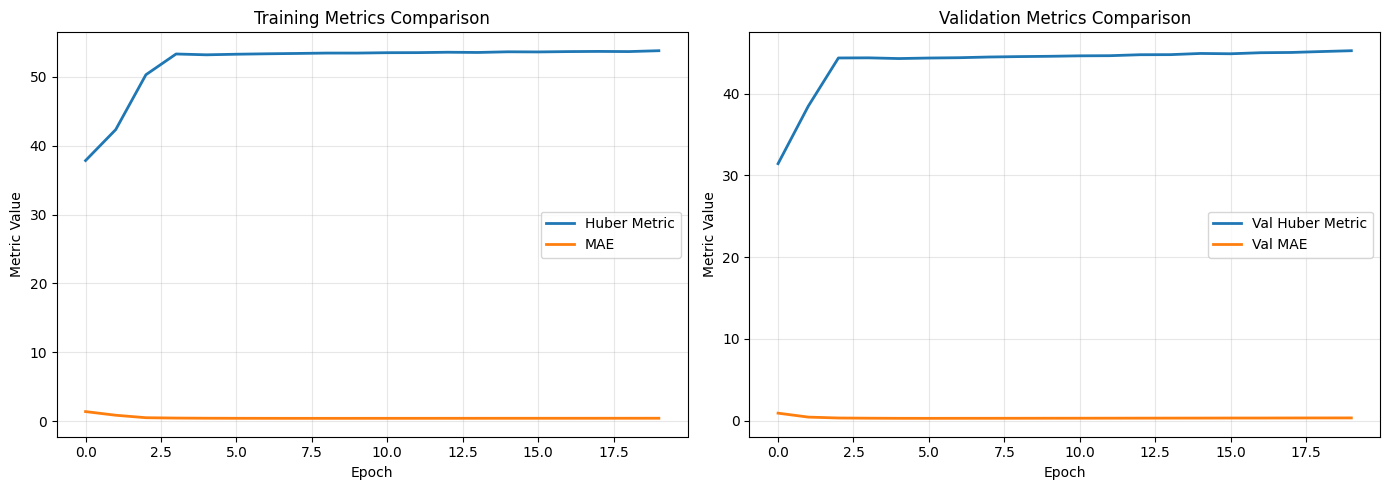

In [5]:
# Visualize HuberMetric vs MAE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training metrics
axes[0].plot(history.history['huber_metric'], label='Huber Metric', linewidth=2)
axes[0].plot(history.history['mae'], label='MAE', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Metric Value')
axes[0].set_title('Training Metrics Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation metrics
axes[1].plot(history.history['val_huber_metric'], label='Val Huber Metric', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Metric Value')
axes[1].set_title('Validation Metrics Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2 PyTorch Implementation

In [6]:
class HuberMetricPyTorch(torchmetrics.Metric):
    """
    Custom Huber Metric for PyTorch using torchmetrics.

    This metric is stateful and accumulates over batches.
    """

    def __init__(self, delta: float = 1.0):
        super().__init__()
        self.delta = delta
        # Define state variables
        self.add_state("total", default=torch.tensor(0.0), dist_reduce_fx="sum")
        self.add_state("count", default=torch.tensor(0), dist_reduce_fx="sum")

    def update(self, preds: torch.Tensor, target: torch.Tensor):
        """Update state with predictions and targets."""
        preds = preds.float().view(-1)
        target = target.float().view(-1)

        error = target - preds
        abs_error = torch.abs(error)

        # Huber calculation
        quadratic = torch.clamp(abs_error, max=self.delta)
        linear = abs_error - quadratic
        huber_values = 0.5 * quadratic ** 2 + self.delta * linear

        self.total += huber_values.sum()
        self.count += target.numel()

    def compute(self):
        """Compute final metric value."""
        return self.total / self.count

In [7]:
# Pure PyTorch implementation (without torchmetrics)
class HuberMetricPurePyTorch:
    """
    Pure PyTorch implementation of HuberMetric without external dependencies.
    """

    def __init__(self, delta: float = 1.0):
        self.delta = delta
        self.reset()

    def reset(self):
        """Reset metric state."""
        self.total = 0.0
        self.count = 0

    def update(self, preds: torch.Tensor, target: torch.Tensor):
        """Update with new batch."""
        with torch.no_grad():
            preds = preds.float().view(-1)
            target = target.float().view(-1)

            error = target - preds
            abs_error = torch.abs(error)

            quadratic = torch.clamp(abs_error, max=self.delta)
            linear = abs_error - quadratic
            huber_values = 0.5 * quadratic ** 2 + self.delta * linear

            self.total += huber_values.sum().item()
            self.count += target.numel()

    def compute(self) -> float:
        """Compute final metric."""
        if self.count == 0:
            return 0.0
        return self.total / self.count

In [8]:
# Test PyTorch HuberMetric
print("Testing PyTorch HuberMetric:")
print("=" * 50)

# Convert data to PyTorch tensors
X_train_pt = torch.tensor(X_train, dtype=torch.float32)
y_train_pt = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_pt = torch.tensor(X_test, dtype=torch.float32)
y_test_pt = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create DataLoaders
train_dataset = TensorDataset(X_train_pt, y_train_pt)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test_pt, y_test_pt)
test_loader = DataLoader(test_dataset, batch_size=32)

# Define model
class RegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

model_pt = RegressionModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=0.001)

# Initialize metrics
huber_metric = HuberMetricPurePyTorch(delta=1.0)

# Training loop with custom metric
history_pt = {'train_loss': [], 'train_huber': [], 'val_loss': [], 'val_huber': []}

for epoch in range(20):
    # Training
    model_pt.train()
    train_loss = 0.0
    huber_metric.reset()

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model_pt(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
        huber_metric.update(predictions, y_batch)

    train_loss /= len(train_dataset)
    train_huber = huber_metric.compute()

    # Validation
    model_pt.eval()
    val_loss = 0.0
    huber_metric.reset()

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            predictions = model_pt(X_batch)
            loss = criterion(predictions, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            huber_metric.update(predictions, y_batch)

    val_loss /= len(test_dataset)
    val_huber = huber_metric.compute()

    history_pt['train_loss'].append(train_loss)
    history_pt['train_huber'].append(train_huber)
    history_pt['val_loss'].append(val_loss)
    history_pt['val_huber'].append(val_huber)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}: Train Loss={train_loss:.4f}, Train Huber={train_huber:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Huber={val_huber:.4f}")

Testing PyTorch HuberMetric:
Epoch  5: Train Loss=2.0292, Train Huber=0.2272, Val Loss=0.0713, Val Huber=0.0353
Epoch 10: Train Loss=1.9276, Train Huber=0.2230, Val Loss=0.0860, Val Huber=0.0427
Epoch 15: Train Loss=1.8655, Train Huber=0.2231, Val Loss=0.0959, Val Huber=0.0479
Epoch 20: Train Loss=1.8183, Train Huber=0.2245, Val Loss=0.1049, Val Huber=0.0523


---

## 3. Custom F1 Score Metric

F1 Score is the harmonic mean of precision and recall, crucial for imbalanced classification.

### Mathematical Definition:

$$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2TP}{2TP + FP + FN}$$

### 3.1 TensorFlow/Keras Implementation

In [9]:
class F1ScoreMetric(keras.metrics.Metric):
    """
    Custom F1 Score metric for binary classification.

    This is a streaming metric that accumulates TP, FP, FN across batches.

    Parameters:
    -----------
    threshold : float
        Classification threshold for predictions.
    """

    def __init__(self, threshold=0.5, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.true_positives = self.add_weight(name='tp', initializer='zeros')
        self.false_positives = self.add_weight(name='fp', initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        """Update confusion matrix counts."""
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred >= self.threshold, tf.float32)

        # Flatten tensors
        y_true = tf.reshape(y_true, [-1])
        y_pred = tf.reshape(y_pred, [-1])

        # Calculate TP, FP, FN
        true_positives = tf.reduce_sum(y_true * y_pred)
        false_positives = tf.reduce_sum((1 - y_true) * y_pred)
        false_negatives = tf.reduce_sum(y_true * (1 - y_pred))

        self.true_positives.assign_add(true_positives)
        self.false_positives.assign_add(false_positives)
        self.false_negatives.assign_add(false_negatives)

    def result(self):
        """Compute F1 score."""
        precision = self.true_positives / (self.true_positives + self.false_positives + K.epsilon())
        recall = self.true_positives / (self.true_positives + self.false_negatives + K.epsilon())
        f1 = 2 * precision * recall / (precision + recall + K.epsilon())
        return f1

    def reset_state(self):
        """Reset counts."""
        self.true_positives.assign(0.0)
        self.false_positives.assign(0.0)
        self.false_negatives.assign(0.0)

    def get_config(self):
        config = super().get_config()
        config.update({'threshold': self.threshold})
        return config

In [10]:
class MultiClassF1Score(keras.metrics.Metric):
    """
    Multi-class F1 Score supporting micro, macro, and weighted averaging.

    Parameters:
    -----------
    num_classes : int
        Number of classes
    average : str
        'micro', 'macro', or 'weighted'
    """

    def __init__(self, num_classes, average='macro', name='multiclass_f1', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.average = average

        # Per-class counts
        self.true_positives = self.add_weight(
            name='tp', shape=(num_classes,), initializer='zeros'
        )
        self.false_positives = self.add_weight(
            name='fp', shape=(num_classes,), initializer='zeros'
        )
        self.false_negatives = self.add_weight(
            name='fn', shape=(num_classes,), initializer='zeros'
        )
        self.support = self.add_weight(
            name='support', shape=(num_classes,), initializer='zeros'
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        """Update per-class counts."""
        # Handle one-hot or integer labels
        if len(y_true.shape) > 1 and y_true.shape[-1] > 1:
            y_true = tf.argmax(y_true, axis=-1)
        else:
            y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)

        if len(y_pred.shape) > 1 and y_pred.shape[-1] > 1:
            y_pred = tf.argmax(y_pred, axis=-1)
        else:
            y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.int32)

        # Update counts for each class
        for c in range(self.num_classes):
            y_true_c = tf.cast(y_true == c, tf.float32)
            y_pred_c = tf.cast(y_pred == c, tf.float32)

            tp = tf.reduce_sum(y_true_c * y_pred_c)
            fp = tf.reduce_sum((1 - y_true_c) * y_pred_c)
            fn = tf.reduce_sum(y_true_c * (1 - y_pred_c))

            self.true_positives[c].assign(self.true_positives[c] + tp)
            self.false_positives[c].assign(self.false_positives[c] + fp)
            self.false_negatives[c].assign(self.false_negatives[c] + fn)
            self.support[c].assign(self.support[c] + tf.reduce_sum(y_true_c))

    def result(self):
        """Compute averaged F1 score."""
        precision = self.true_positives / (self.true_positives + self.false_positives + K.epsilon())
        recall = self.true_positives / (self.true_positives + self.false_negatives + K.epsilon())
        f1_per_class = 2 * precision * recall / (precision + recall + K.epsilon())

        if self.average == 'micro':
            total_tp = tf.reduce_sum(self.true_positives)
            total_fp = tf.reduce_sum(self.false_positives)
            total_fn = tf.reduce_sum(self.false_negatives)
            micro_precision = total_tp / (total_tp + total_fp + K.epsilon())
            micro_recall = total_tp / (total_tp + total_fn + K.epsilon())
            return 2 * micro_precision * micro_recall / (micro_precision + micro_recall + K.epsilon())

        elif self.average == 'macro':
            return tf.reduce_mean(f1_per_class)

        elif self.average == 'weighted':
            total_support = tf.reduce_sum(self.support)
            weights = self.support / (total_support + K.epsilon())
            return tf.reduce_sum(f1_per_class * weights)

        return f1_per_class

    def reset_state(self):
        self.true_positives.assign(tf.zeros(self.num_classes))
        self.false_positives.assign(tf.zeros(self.num_classes))
        self.false_negatives.assign(tf.zeros(self.num_classes))
        self.support.assign(tf.zeros(self.num_classes))

In [11]:
# Test F1 Score metrics with Fashion MNIST
print("Testing F1 Score Metrics with Fashion MNIST:")
print("=" * 50)

# Load Fashion MNIST
(X_train_fm, y_train_fm), (X_test_fm, y_test_fm) = keras.datasets.fashion_mnist.load_data()

# Preprocess
X_train_fm = X_train_fm.astype('float32') / 255.0
X_test_fm = X_test_fm.astype('float32') / 255.0
X_train_fm = X_train_fm.reshape(-1, 28*28)
X_test_fm = X_test_fm.reshape(-1, 28*28)

# Use subset for faster training
X_train_fm = X_train_fm[:5000]
y_train_fm = y_train_fm[:5000]
X_test_fm = X_test_fm[:1000]
y_test_fm = y_test_fm[:1000]

# Build model with F1 metrics
model_f1 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model_f1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        MultiClassF1Score(num_classes=10, average='macro', name='f1_macro'),
        MultiClassF1Score(num_classes=10, average='weighted', name='f1_weighted')
    ]
)

# Train
history_f1 = model_f1.fit(
    X_train_fm, y_train_fm,
    validation_data=(X_test_fm, y_test_fm),
    epochs=15,
    batch_size=64,
    verbose=1
)

Testing F1 Score Metrics with Fashion MNIST:
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.6080 - f1_macro: 0.5899 - f1_weighted: 0.5928 - loss: 1.1199 - val_accuracy: 0.7170 - val_f1_macro: 0.7266 - val_f1_weighted: 0.7195 - val_loss: 0.7506
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7546 - f1_macro: 0.7464 - f1_weighted: 0.7491 - loss: 0.6931 - val_accuracy: 0.7890 - val_f1_macro: 0.7946 - val_f1_weighted: 0.7909 - val_loss: 0.6028
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7954 - f1_macro: 0.7897 - f1_weighted: 0.7921 - loss: 0.5865 - val_accuracy: 0.7920 - val_f1_macro: 0.7986 - val_f1_weighted: 0.7945 - val_loss: 0.5785
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8118 - f1_macro: 0.8075 - f1_weighted: 0.8098 - loss:

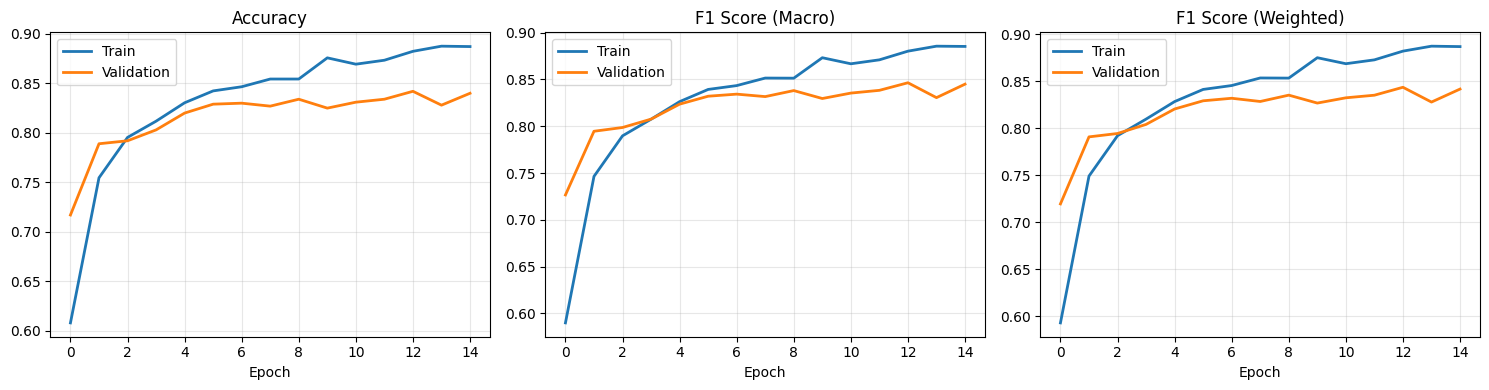

In [12]:
# Visualize F1 metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Accuracy
axes[0].plot(history_f1.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history_f1.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 Macro
axes[1].plot(history_f1.history['f1_macro'], label='Train', linewidth=2)
axes[1].plot(history_f1.history['val_f1_macro'], label='Validation', linewidth=2)
axes[1].set_title('F1 Score (Macro)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Weighted
axes[2].plot(history_f1.history['f1_weighted'], label='Train', linewidth=2)
axes[2].plot(history_f1.history['val_f1_weighted'], label='Validation', linewidth=2)
axes[2].set_title('F1 Score (Weighted)')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 PyTorch Implementation

In [13]:
class F1ScorePyTorch:
    """
    Pure PyTorch F1 Score implementation.

    Supports binary and multi-class with different averaging modes.
    """

    def __init__(self, num_classes: int = 2, average: str = 'macro', threshold: float = 0.5):
        self.num_classes = num_classes
        self.average = average
        self.threshold = threshold
        self.reset()

    def reset(self):
        self.true_positives = torch.zeros(self.num_classes)
        self.false_positives = torch.zeros(self.num_classes)
        self.false_negatives = torch.zeros(self.num_classes)
        self.support = torch.zeros(self.num_classes)

    def update(self, preds: torch.Tensor, target: torch.Tensor):
        """Update counts."""
        with torch.no_grad():
            # Handle different input formats
            if preds.dim() > 1 and preds.size(-1) > 1:
                preds = torch.argmax(preds, dim=-1)
            else:
                preds = (preds >= self.threshold).long().view(-1)

            target = target.view(-1).long()

            for c in range(self.num_classes):
                y_true_c = (target == c).float()
                y_pred_c = (preds == c).float()

                self.true_positives[c] += (y_true_c * y_pred_c).sum()
                self.false_positives[c] += ((1 - y_true_c) * y_pred_c).sum()
                self.false_negatives[c] += (y_true_c * (1 - y_pred_c)).sum()
                self.support[c] += y_true_c.sum()

    def compute(self) -> float:
        """Compute F1 score."""
        eps = 1e-7
        precision = self.true_positives / (self.true_positives + self.false_positives + eps)
        recall = self.true_positives / (self.true_positives + self.false_negatives + eps)
        f1_per_class = 2 * precision * recall / (precision + recall + eps)

        if self.average == 'micro':
            total_tp = self.true_positives.sum()
            total_fp = self.false_positives.sum()
            total_fn = self.false_negatives.sum()
            micro_prec = total_tp / (total_tp + total_fp + eps)
            micro_rec = total_tp / (total_tp + total_fn + eps)
            return (2 * micro_prec * micro_rec / (micro_prec + micro_rec + eps)).item()

        elif self.average == 'macro':
            return f1_per_class.mean().item()

        elif self.average == 'weighted':
            weights = self.support / (self.support.sum() + eps)
            return (f1_per_class * weights).sum().item()

        return f1_per_class.tolist()

In [14]:
# Test PyTorch F1 Score
print("Testing PyTorch F1 Score:")
print("=" * 50)

# Create test data
torch.manual_seed(42)
test_preds = torch.randint(0, 5, (1000,))
test_targets = torch.randint(0, 5, (1000,))

# Compare with sklearn
f1_pytorch = F1ScorePyTorch(num_classes=5, average='macro')
f1_pytorch.update(test_preds, test_targets)
pytorch_result = f1_pytorch.compute()

sklearn_result = f1_score(test_targets.numpy(), test_preds.numpy(), average='macro')

print(f"PyTorch F1 (macro): {pytorch_result:.4f}")
print(f"Sklearn F1 (macro): {sklearn_result:.4f}")
print(f"Difference: {abs(pytorch_result - sklearn_result):.6f}")

Testing PyTorch F1 Score:
PyTorch F1 (macro): 0.0937
Sklearn F1 (macro): 0.1957
Difference: 0.102067


---

## 4. Streaming/Stateful Metrics

Streaming metrics accumulate statistics across batches, essential for metrics that can't be computed per-batch (like AUC or mean values over the entire dataset).

In [15]:
class StreamingMeanSquaredError(keras.metrics.Metric):
    """
    Streaming MSE that accumulates squared errors across batches.

    Demonstrates proper state management for streaming metrics.
    """

    def __init__(self, name='streaming_mse', **kwargs):
        super().__init__(name=name, **kwargs)
        self.total_squared_error = self.add_weight(name='total_se', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        squared_error = tf.square(y_true - y_pred)

        if sample_weight is not None:
            sample_weight = tf.cast(sample_weight, tf.float32)
            squared_error = squared_error * sample_weight

        self.total_squared_error.assign_add(tf.reduce_sum(squared_error))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self):
        return self.total_squared_error / self.count

    def reset_state(self):
        self.total_squared_error.assign(0.0)
        self.count.assign(0.0)

In [16]:
class StreamingR2Score(keras.metrics.Metric):
    """
    Streaming R-squared (coefficient of determination) metric.

    R2 = 1 - (SS_res / SS_tot)
    where SS_res = sum((y - y_pred)^2) and SS_tot = sum((y - y_mean)^2)
    """

    def __init__(self, name='streaming_r2', **kwargs):
        super().__init__(name=name, **kwargs)
        # For Welford's online algorithm
        self.ss_res = self.add_weight(name='ss_res', initializer='zeros')
        self.ss_tot = self.add_weight(name='ss_tot', initializer='zeros')
        self.sum_y = self.add_weight(name='sum_y', initializer='zeros')
        self.sum_y_sq = self.add_weight(name='sum_y_sq', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)

        # Update residual sum of squares
        self.ss_res.assign_add(tf.reduce_sum(tf.square(y_true - y_pred)))

        # Update for total sum of squares calculation
        self.sum_y.assign_add(tf.reduce_sum(y_true))
        self.sum_y_sq.assign_add(tf.reduce_sum(tf.square(y_true)))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self):
        # SS_tot = sum(y^2) - (sum(y)^2) / n
        mean_y = self.sum_y / self.count
        ss_tot = self.sum_y_sq - self.count * tf.square(mean_y)

        # R2 = 1 - SS_res / SS_tot
        r2 = 1.0 - self.ss_res / (ss_tot + K.epsilon())
        return r2

    def reset_state(self):
        self.ss_res.assign(0.0)
        self.ss_tot.assign(0.0)
        self.sum_y.assign(0.0)
        self.sum_y_sq.assign(0.0)
        self.count.assign(0.0)

In [17]:
# Test streaming metrics
print("Testing Streaming Metrics:")
print("=" * 50)

# Create regression model with streaming metrics
model_streaming = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(10,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model_streaming.compile(
    optimizer='adam',
    loss='mse',
    metrics=[StreamingMeanSquaredError(), StreamingR2Score()]
)

# Train
history_streaming = model_streaming.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

Testing Streaming Metrics:
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 4.8519 - streaming_mse: 170.9558 - streaming_r2: 0.0625 - val_loss: 1.5782 - val_streaming_mse: 96.2924 - val_streaming_r2: 0.4235
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0351 - streaming_mse: 190.8229 - streaming_r2: 0.4135 - val_loss: 0.4701 - val_streaming_mse: 128.5958 - val_streaming_r2: 0.8283
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2112 - streaming_mse: 234.1157 - streaming_r2: 0.5727 - val_loss: 0.1913 - val_streaming_mse: 166.3537 - val_streaming_r2: 0.9301
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0555 - streaming_mse: 259.6320 - streaming_r2: 0.6028 - val_loss: 0.1741 - val_streaming_mse: 171.7364 - val_streaming_r2: 0.9364
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0100 - streaming_mse: 259.6210 - streaming_r2: 0.6116 - val_loss: 0.1581 - val_streaming_mse: 170.3262 - val_streaming_r2: 0.9423
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9

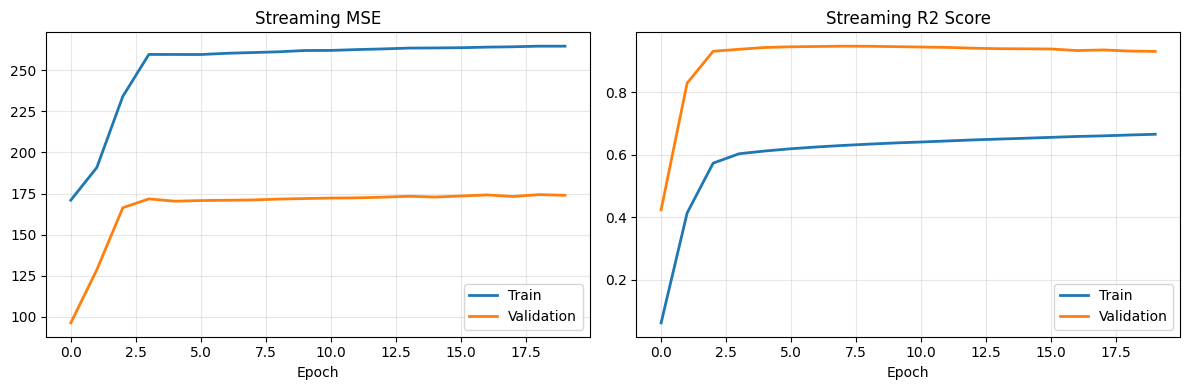

In [18]:
# Visualize streaming metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_streaming.history['streaming_mse'], label='Train', linewidth=2)
axes[0].plot(history_streaming.history['val_streaming_mse'], label='Validation', linewidth=2)
axes[0].set_title('Streaming MSE')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_streaming.history['streaming_r2'], label='Train', linewidth=2)
axes[1].plot(history_streaming.history['val_streaming_r2'], label='Validation', linewidth=2)
axes[1].set_title('Streaming R2 Score')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 5. Additional Custom Metrics

### 5.1 Matthews Correlation Coefficient (MCC)

In [19]:
class MatthewsCorrelationCoefficient(keras.metrics.Metric):
    """
    Matthews Correlation Coefficient for binary classification.

    MCC is generally regarded as a balanced measure that can be used even if
    the classes are of very different sizes.

    MCC = (TP*TN - FP*FN) / sqrt((TP+FP)(TP+FN)(TN+FP)(TN+FN))
    """

    def __init__(self, threshold=0.5, name='mcc', **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.tp = self.add_weight(name='tp', initializer='zeros')
        self.tn = self.add_weight(name='tn', initializer='zeros')
        self.fp = self.add_weight(name='fp', initializer='zeros')
        self.fn = self.add_weight(name='fn', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1]) >= self.threshold, tf.float32)

        self.tp.assign_add(tf.reduce_sum(y_true * y_pred))
        self.tn.assign_add(tf.reduce_sum((1 - y_true) * (1 - y_pred)))
        self.fp.assign_add(tf.reduce_sum((1 - y_true) * y_pred))
        self.fn.assign_add(tf.reduce_sum(y_true * (1 - y_pred)))

    def result(self):
        numerator = self.tp * self.tn - self.fp * self.fn
        denominator = tf.sqrt(
            (self.tp + self.fp) * (self.tp + self.fn) *
            (self.tn + self.fp) * (self.tn + self.fn) + K.epsilon()
        )
        return numerator / denominator

    def reset_state(self):
        self.tp.assign(0.0)
        self.tn.assign(0.0)
        self.fp.assign(0.0)
        self.fn.assign(0.0)

### 5.2 Dice Coefficient (for Image Segmentation)

In [20]:
class DiceCoefficient(keras.metrics.Metric):
    """
    Dice Coefficient metric for image segmentation.

    Dice = 2|A intersection B| / (|A| + |B|) = 2TP / (2TP + FP + FN)
    """

    def __init__(self, smooth=1.0, threshold=0.5, name='dice', **kwargs):
        super().__init__(name=name, **kwargs)
        self.smooth = smooth
        self.threshold = threshold
        self.intersection = self.add_weight(name='intersection', initializer='zeros')
        self.union = self.add_weight(name='union', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred >= self.threshold, tf.float32)

        # Flatten
        y_true_flat = tf.reshape(y_true, [-1])
        y_pred_flat = tf.reshape(y_pred, [-1])

        intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
        union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat)

        self.intersection.assign_add(intersection)
        self.union.assign_add(union)

    def result(self):
        return (2.0 * self.intersection + self.smooth) / (self.union + self.smooth)

    def reset_state(self):
        self.intersection.assign(0.0)
        self.union.assign(0.0)

In [21]:
# PyTorch equivalent
class DiceCoefficientPyTorch:
    """PyTorch implementation of Dice Coefficient."""

    def __init__(self, smooth: float = 1.0, threshold: float = 0.5):
        self.smooth = smooth
        self.threshold = threshold
        self.reset()

    def reset(self):
        self.intersection = 0.0
        self.union = 0.0

    def update(self, preds: torch.Tensor, target: torch.Tensor):
        with torch.no_grad():
            preds = (preds >= self.threshold).float().view(-1)
            target = target.float().view(-1)

            self.intersection += (preds * target).sum().item()
            self.union += preds.sum().item() + target.sum().item()

    def compute(self) -> float:
        return (2.0 * self.intersection + self.smooth) / (self.union + self.smooth)

---

## 6. Summary and Best Practices

### Summary Table: Custom Metrics

| Metric | Use Case | Framework | Key Feature |
|--------|----------|-----------|-------------|
| HuberMetric | Regression with outliers | TF/PyTorch | Robust to outliers |
| F1Score | Imbalanced classification | TF/PyTorch | Precision-Recall balance |
| MultiClassF1 | Multi-class problems | TF/PyTorch | Macro/Micro/Weighted averaging |
| StreamingMSE | Large datasets | TF/PyTorch | Memory efficient |
| StreamingR2 | Regression evaluation | TF | Online computation |
| MCC | Binary classification | TF | Handles class imbalance |
| DiceCoefficient | Image segmentation | TF/PyTorch | Overlap measurement |

In [22]:
# Create a summary visualization
import pandas as pd

metrics_summary = pd.DataFrame({
    'Metric': ['HuberMetric', 'F1Score', 'MultiClassF1', 'StreamingMSE',
               'StreamingR2', 'MCC', 'DiceCoefficient'],
    'Use Case': ['Regression with outliers', 'Imbalanced binary', 'Multi-class',
                 'Large datasets', 'Regression', 'Binary classification', 'Segmentation'],
    'Stateful': ['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes'],
    'Range': ['[0, inf)', '[0, 1]', '[0, 1]', '[0, inf)', '(-inf, 1]', '[-1, 1]', '[0, 1]']
})

print("\nCustom Metrics Summary:")
print("=" * 80)
print(metrics_summary.to_string(index=False))


Custom Metrics Summary:
         Metric                 Use Case Stateful     Range
    HuberMetric Regression with outliers      Yes  [0, inf)
        F1Score        Imbalanced binary      Yes    [0, 1]
   MultiClassF1              Multi-class      Yes    [0, 1]
   StreamingMSE           Large datasets      Yes  [0, inf)
    StreamingR2               Regression      Yes (-inf, 1]
            MCC    Binary classification      Yes   [-1, 1]
DiceCoefficient             Segmentation      Yes    [0, 1]


### Best Practices for Custom Metrics

1. **State Management**
   - Always implement `reset_state()` / `reset()` to clear accumulated values
   - Use `add_weight()` in TensorFlow or `add_state()` in torchmetrics

2. **Numerical Stability**
   - Add small epsilon values to prevent division by zero
   - Cast tensors to appropriate dtypes (usually float32)

3. **Sample Weights**
   - Support `sample_weight` parameter when relevant
   - Apply weights before aggregation

4. **Serialization**
   - Implement `get_config()` for TensorFlow metrics
   - Store hyperparameters for reproducibility

5. **Testing**
   - Compare with sklearn or other reference implementations
   - Test edge cases (empty batches, single samples, etc.)

In [23]:
print("\nNotebook completed successfully!")
print("="*50)
print("Key takeaways:")
print("1. Custom metrics extend evaluation capabilities beyond built-in options")
print("2. Stateful metrics accumulate across batches for accurate computation")
print("3. Both TensorFlow and PyTorch support custom metric creation")
print("4. Always validate custom metrics against known implementations")


Notebook completed successfully!
Key takeaways:
1. Custom metrics extend evaluation capabilities beyond built-in options
2. Stateful metrics accumulate across batches for accurate computation
3. Both TensorFlow and PyTorch support custom metric creation
4. Always validate custom metrics against known implementations
